In [1]:
import sys
import os
from pathlib import Path
import json
from dataclasses import asdict

# Add the backend directory to the path
backend_path = Path.cwd()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.services.tools.parse_structured_query import parse_structured_query, StructuredQuery


# Testing parse_structured_query.py

This notebook tests the query parser with various question types to see how they are parsed into structured queries.


In [2]:
# Define all test questions
questions = [
    # 1. Degree progress / requirements
    ("Degree progress / requirements", "What classes should I take next quarter to stay on track for the Data Science major?"),
    ("Degree progress / requirements", "I still need two STAT electives and one CS class — what do you recommend?"),
    ("Degree progress / requirements", "Which courses can double count for my Data Science major and Italian minor?"),
    ("Degree progress / requirements", "I have AP credit for Calc BC and Statistics — what should I take next?"),
    ("Degree progress / requirements", "What's the easiest way to finish my Transportation & Logistics minor by junior year?"),
    
    # 2. Interest-driven recommendations
    ("Interest-driven recommendations", "I like machine learning and linguistics — what classes combine both?"),
    ("Interest-driven recommendations", "Recommend classes related to NLP or computational linguistics."),
    ("Interest-driven recommendations", "I'm interested in urban planning and transportation systems — any good electives?"),
    ("Interest-driven recommendations", "What classes would help me get into data analytics internships?"),
    ("Interest-driven recommendations", "I enjoyed STAT 303 and CS 211 — what should I take next?"),
    
    # 3. Difficulty / workload constraints
    ("Difficulty / workload constraints", "I want a lighter quarter — what are some low-workload electives?"),
    ("Difficulty / workload constraints", "Recommend rigorous, math-heavy classes for someone who likes theory."),
    ("Difficulty / workload constraints", "I'm taking two hard STAT classes already — what's a chill fourth class?"),
    ("Difficulty / workload constraints", "Which classes are challenging but fair (not busywork-heavy)?"),
    
    # 4. Schedule / logistics constraints
    ("Schedule / logistics constraints", "What classes fit into a Monday–Wednesday schedule with no mornings?"),
    ("Schedule / logistics constraints", "Recommend classes with no Friday sections."),
    ("Schedule / logistics constraints", "I need a class after 2pm that counts toward my major."),
    ("Schedule / logistics constraints", "What courses won't conflict with my existing schedule?"),
    
    # 5. Professor / style preferences
    ("Professor / style preferences", "Are there any Data Science classes taught by professors known for clear lectures?"),
    ("Professor / style preferences", "Which professors are best if I prefer project-based classes over exams?"),
]

print(f"Total questions to test: {len(questions)}")


Total questions to test: 20


In [4]:
# Helper function to format query results
def format_query_dict(query: StructuredQuery) -> dict:
    """Convert StructuredQuery to a dict, filtering out empty fields."""
    d = asdict(query)
    # Filter out empty lists and None values (except original_message)
    filtered = {}
    for k, v in d.items():
        if k == "original_message":
            filtered[k] = v
        elif v:  # Only include non-empty values
            if isinstance(v, list) and len(v) > 0:
                filtered[k] = v
            elif not isinstance(v, list) and v is not None:
                filtered[k] = v
    return filtered

# Parse all questions
results = []
for category, question in questions:
    try:
        query = parse_structured_query(question)
        result_dict = format_query_dict(query)
        results.append({
            "category": category,
            "question": question,
            "parsed": result_dict,
            "query_obj": query
        })
    except Exception as e:
        results.append({
            "category": category,
            "question": question,
            "error": str(e),
            "error_type": type(e).__name__
        })

print(f"Successfully parsed {len([r for r in results if 'error' not in r])} out of {len(questions)} questions")


Successfully parsed 20 out of 20 questions


## Results by Category

Let's view the parsed results for each question:


In [5]:
# Display results in a readable format
import pandas as pd

# Create a summary table
summary_data = []
for r in results:
    if 'error' in r:
        summary_data.append({
            "Category": r["category"],
            "Question": r["question"][:80] + "..." if len(r["question"]) > 80 else r["question"],
            "Subjects": "ERROR",
            "Days": "",
            "Time Windows": "",
            "Keywords": ""
        })
    else:
        parsed = r["parsed"]
        summary_data.append({
            "Category": r["category"],
            "Question": r["question"][:80] + "..." if len(r["question"]) > 80 else r["question"],
            "Subjects": ", ".join(parsed.get("subjects", [])),
            "Days": ", ".join(parsed.get("days", [])),
            "Time Windows": str(parsed.get("time_windows", [])),
            "Keywords": ", ".join(parsed.get("keywords", [])[:5])  # First 5 keywords
        })

df_summary = pd.DataFrame(summary_data)
df_summary


,Category,Question,Subjects,Days,Time Windows,Keywords
0,Degree progress / requirements,What classes should I take next quarter to sta...,,,[],
1,Degree progress / requirements,I still need two STAT electives and one CS cla...,"STAT, COMP_SCI",,[],
2,Degree progress / requirements,Which courses can double count for my Data Sci...,,,[],
3,Degree progress / requirements,I have AP credit for Calc BC and Statistics — ...,,,[],
4,Degree progress / requirements,What's the easiest way to finish my Transporta...,,,[],
5,Interest-driven recommendations,I like machine learning and linguistics — what...,,,[],
6,Interest-driven recommendations,Recommend classes related to NLP or computatio...,,,[],
7,Interest-driven recommendations,I'm interested in urban planning and transport...,,,[],
8,Interest-driven recommendations,What classes would help me get into data analy...,,,[],
9,Interest-driven recommendations,I enjoyed STAT 303 and CS 211 — what should I ...,,,[],


## Detailed Results

View the full parsed structure for each question:


In [6]:
# Display detailed results for each question
for i, r in enumerate(results, 1):
    print(f"\n{'='*100}")
    print(f"Question {i}: {r['category']}")
    print(f"{'-'*100}")
    print(f"Original: {r['question']}")
    print(f"{'-'*100}")
    
    if 'error' in r:
        print(f"❌ ERROR: {r['error_type']}: {r['error']}")
    else:
        parsed = r['parsed']
        # Pretty print the parsed structure
        print(json.dumps(parsed, indent=2, default=str))
    
    print(f"{'='*100}\n")



Question 1: Degree progress / requirements
----------------------------------------------------------------------------------------------------
Original: What classes should I take next quarter to stay on track for the Data Science major?
----------------------------------------------------------------------------------------------------
{
  "exclude_placeholder": true,
  "include_keywords": [
    "data science",
    "statistics",
    "programming",
    "machine learning",
    "data analysis",
    "big data",
    "data visualization",
    "data mining"
  ],
  "priority": {
    "weights": {},
    "hard": [],
    "soft": [
      "include_keywords"
    ]
  },
  "notes": "User is looking for courses relevant to staying on track for a Data Science major.",
  "original_message": "What classes should I take next quarter to stay on track for the Data Science major?"
}


Question 2: Degree progress / requirements
---------------------------------------------------------------------------------

## Interactive Exploration

You can access individual results by category or question number:


In [6]:
# Example: View results by category
def view_by_category(category_name):
    """View all results for a specific category."""
    category_results = [r for r in results if r['category'] == category_name]
    print(f"\n{'='*100}")
    print(f"Category: {category_name} ({len(category_results)} questions)")
    print(f"{'='*100}\n")
    
    for i, r in enumerate(category_results, 1):
        print(f"\nQuestion {i}:")
        print(f"  Original: {r['question']}")
        if 'error' in r:
            print(f"  ❌ ERROR: {r['error']}")
        else:
            parsed = r['parsed']
            print(f"  Parsed: {json.dumps(parsed, indent=4, default=str)}")
        print()

# List available categories
categories = list(set(r['category'] for r in results))
print("Available categories:")
for cat in categories:
    count = len([r for r in results if r['category'] == cat])
    print(f"  - {cat} ({count} questions)")

print("\nTo view results for a category, run:")
print("  view_by_category('Category Name')")


Available categories:
  - Degree progress / requirements (5 questions)
  - Schedule / logistics constraints (4 questions)
  - Difficulty / workload constraints (4 questions)
  - Interest-driven recommendations (5 questions)
  - Professor / style preferences (2 questions)

To view results for a category, run:
  view_by_category('Category Name')


In [7]:
# Example: Access a specific question's parsed result
# Change the index to view different questions (0-indexed)
question_index = 0  # Change this to view different questions

if question_index < len(results):
    r = results[question_index]
    print(f"Question {question_index + 1}:")
    print(f"Category: {r['category']}")
    print(f"Original: {r['question']}\n")
    
    if 'error' in r:
        print(f"❌ ERROR: {r['error']}")
    else:
        print("Parsed Structure:")
        print(json.dumps(r['parsed'], indent=2, default=str))
        
        # You can also access the StructuredQuery object directly
        print("\n\nAccess the StructuredQuery object via:")
        print(f"  results[{question_index}]['query_obj']")
else:
    print(f"Invalid index. Please use 0-{len(results)-1}")


Question 1:
Category: Degree progress / requirements
Original: What classes should I take next quarter to stay on track for the Data Science major?

Parsed Structure:
{
  "keywords": [
    "classes",
    "next",
    "quarter",
    "stay",
    "track",
    "Data",
    "Science",
    "major"
  ],
  "notes": "The user is looking for classes relevant to the Data Science major.",
  "original_message": "What classes should I take next quarter to stay on track for the Data Science major?"
}


Access the StructuredQuery object via:
  results[0]['query_obj']


In [8]:
for i in range(20):
    print(results[i]["query_obj"])

StructuredQuery(term=None, subjects=[], level_range=[], distros=[], days=[], time_windows=[], schools=[], instructors=[], avoidSubjects=[], avoidInstructors=[], days_exclude=[], time_exclude=[], levels_exclude=[], keywords=['classes', 'next', 'quarter', 'stay', 'track', 'Data', 'Science', 'major'], notes='The user is looking for classes relevant to the Data Science major.', original_message='What classes should I take next quarter to stay on track for the Data Science major?')
StructuredQuery(term=None, subjects=['STAT', 'COMP_SCI'], level_range=[], distros=[], days=[], time_windows=[], schools=[], instructors=[], avoidSubjects=[], avoidInstructors=[], days_exclude=[], time_exclude=[], levels_exclude=[], keywords=['electives', 'class', 'recommend'], notes='', original_message='I still need two STAT electives and one CS class — what do you recommend?')
StructuredQuery(term=None, subjects=['STAT', 'ITALIAN'], level_range=[], distros=[], days=[], time_windows=[], schools=[], instructors=[

## Field Extraction Summary

Let's see what fields are being extracted across all questions:


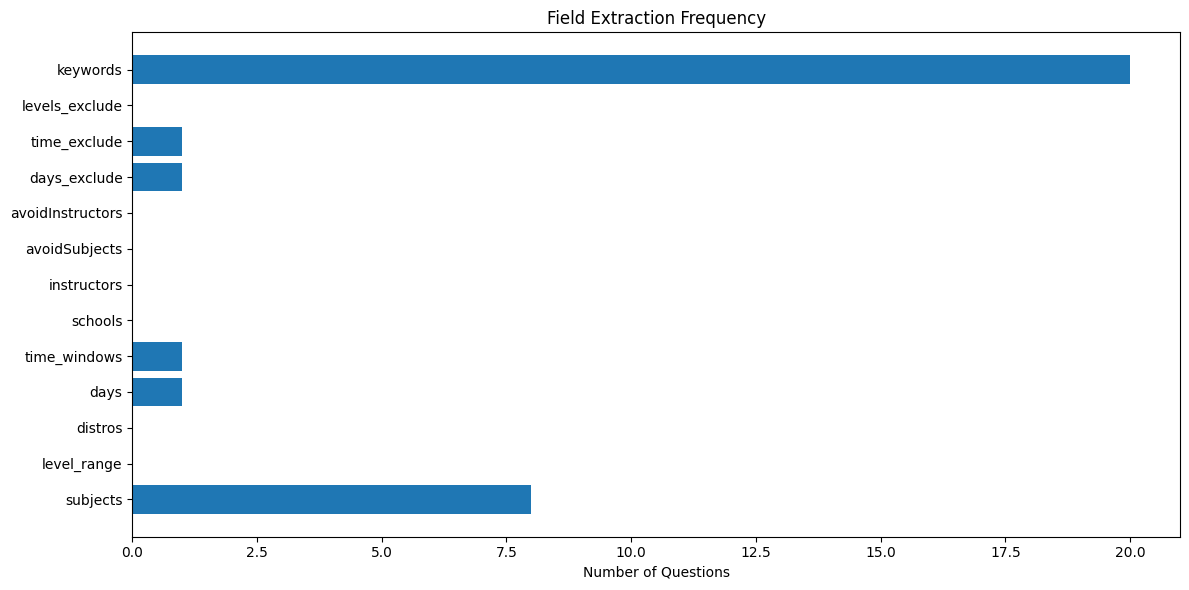


Field extraction summary:
  keywords: 20 questions
  subjects: 8 questions
  days: 1 questions
  time_windows: 1 questions
  days_exclude: 1 questions
  time_exclude: 1 questions


In [8]:
# Count how many questions extract each field type
field_counts = {
    "subjects": 0,
    "level_range": 0,
    "distros": 0,
    "days": 0,
    "time_windows": 0,
    "schools": 0,
    "instructors": 0,
    "avoidSubjects": 0,
    "avoidInstructors": 0,
    "days_exclude": 0,
    "time_exclude": 0,
    "levels_exclude": 0,
    "keywords": 0,
}

for r in results:
    if 'error' not in r:
        parsed = r['parsed']
        for field in field_counts.keys():
            if field in parsed:
                field_counts[field] += 1

# Display as a bar chart
import matplotlib.pyplot as plt

fields = list(field_counts.keys())
counts = list(field_counts.values())

plt.figure(figsize=(12, 6))
plt.barh(fields, counts)
plt.xlabel('Number of Questions')
plt.title('Field Extraction Frequency')
plt.tight_layout()
plt.show()

print("\nField extraction summary:")
for field, count in sorted(field_counts.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        print(f"  {field}: {count} questions")


In [1]:
from app.services.tools.shortlist_classes import shortlist_classes
from app.services.tools.parse_structured_query import parse_structured_query

# Parse a query
query = parse_structured_query("I need STAT classes after 2pm with no Friday please")

# Get shortlist
result = shortlist_classes(query, limit=20, per_subject_cap=6)

# Access results
for course in result["shortlist"]:
    print(f"{course['subject']} {course['catalog_number']}: {course['title']}")

STAT 202-SG: Peer-Guided Study Group: Introduction to Statistics and Data Science
STAT 210-0: Introduction to Probability and Statistics
STAT 210-SG: Peer-Guided Study Group: Introduction to Probability and Statistics
STAT 301-1: Data Science 1 with R
STAT 302-0: Data Visualization
STAT 303-1: Data Science 1 with Python
